In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

# Step 1 - Load Dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Netflix_EDA/netflix_regression_capstone_dataset - netflix_regression_capstone_dataset.csv')
df

,show_id,title,release_type,genre,language,country,release_year,release_day,duration_minutes,number_of_seasons,total_episodes,budget_million_usd,marketing_spend_million_usd,cast_popularity_score,director_popularity_score,imdb_rating,critic_score,trailer_views_million,social_media_mentions_k,subscription_plan_popularity,watch_hours_million
0,NFX000001,Adaptive disintermediate alliance,Movie,Drama,French,South Korea,2020,Tuesday,116,0,1,54.93,26.33,6.39,2.40,5.9,67.1,57.27,243.33,Basic,274.30
1,NFX000002,Re-contextualized transitional benchmark,Movie,Comedy,French,Japan,2023,Friday,107,0,1,26.52,4.06,1.21,5.72,4.9,50.8,5.89,45.36,Basic,102.28
2,NFX000003,Adaptive asymmetric conglomeration,Series,Drama,English,USA,2016,Tuesday,94,4,48,47.44,10.76,1.59,9.54,5.8,55.7,28.20,95.87,Basic,208.64
3,NFX000004,Persevering content-based architecture,Movie,Fantasy,Hindi,Japan,2016,Saturday,114,0,1,21.82,9.78,3.81,5.68,4.8,53.9,26.08,113.52,Premium,141.91
4,NFX000005,Ameliorated encompassing neural-net,Series,Sci-Fi,Korean,Spain,2017,Wednesday,88,1,12,91.81,53.65,6.46,3.48,7.4,69.9,100.11,391.46,Basic,509.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,NFX024996,Function-based zero-defect utilization,Series,Documentary,Hindi,India,2015,Monday,100,1,13,40.31,14.08,3.39,9.61,6.2,64.9,24.46,132.79,Basic,192.95
24996,NFX024997,Exclusive web-enabled emulation,Series,Comedy,French,South Korea,2024,Thursday,93,1,13,57.16,25.83,2.82,4.96,4.8,54.0,52.09,206.98,Premium,293.39
24997,NFX024998,Robust demand-driven Internet solution,Movie,Fantasy,French,Spain,2023,Monday,154,0,1,46.94,26.20,3.88,1.58,5.2,48.4,56.03,225.38,Premium,279.97
24998,NFX024999,Triple-buffered intangible hardware,Movie,Thriller,German,South Korea,2015,Wednesday,156,0,1,50.72,27.68,1.54,8.96,6.7,71.0,47.76,153.36,Standard,300.42


# Step 2 - Understand the Dataset

We first inspect:
- Data types
- Missing values
- Statistical summary


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   show_id                       25000 non-null  object 
 1   title                         25000 non-null  object 
 2   release_type                  25000 non-null  object 
 3   genre                         25000 non-null  object 
 4   language                      25000 non-null  object 
 5   country                       25000 non-null  object 
 6   release_year                  25000 non-null  int64  
 7   release_day                   25000 non-null  object 
 8   duration_minutes              25000 non-null  int64  
 9   number_of_seasons             25000 non-null  int64  
 10  total_episodes                25000 non-null  int64  
 11  budget_million_usd            25000 non-null  float64
 12  marketing_spend_million_usd   25000 non-null  float64
 13  c

In [4]:
df.isnull().sum()

,0
show_id,0
title,0
release_type,0
genre,0
language,0
country,0
release_year,0
release_day,0
duration_minutes,0
number_of_seasons,0


In [5]:
df.describe()

,release_year,duration_minutes,number_of_seasons,total_episodes,budget_million_usd,marketing_spend_million_usd,cast_popularity_score,director_popularity_score,imdb_rating,critic_score,trailer_views_million,social_media_mentions_k,watch_hours_million
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2020.455960,109.646280,1.977200,20.320560,45.234921,17.003701,5.494800,5.515754,6.460124,64.593880,41.621048,184.511095,254.140916
std,3.460483,24.510603,2.445755,25.417469,19.594853,9.761252,2.597302,2.608319,1.291745,15.043583,18.973568,73.500029,82.719162
min,2015.000000,60.000000,0.000000,1.000000,5.000000,0.750000,1.000000,1.000000,1.700000,20.000000,1.000000,5.000000,20.000000
25%,2017.000000,93.000000,0.000000,1.000000,31.580000,9.690000,3.230000,3.240000,5.600000,54.400000,27.770000,131.680000,195.490000
50%,2020.000000,109.000000,0.000000,1.000000,45.060000,15.290000,5.500000,5.530000,6.500000,64.500000,39.140000,179.585000,247.975000
75%,2023.000000,126.000000,4.000000,36.000000,58.500000,22.920000,7.740000,7.760000,7.400000,74.900000,53.420000,231.705000,307.080000
max,2026.000000,227.000000,7.000000,98.000000,127.960000,65.520000,10.000000,10.000000,10.000000,100.000000,133.760000,500.000000,681.560000


In [7]:
df.describe(include='object')

,show_id,title,release_type,genre,language,country,release_day,subscription_plan_popularity
count,25000,25000,25000,25000,25000,25000,25000,25000
unique,25000,24742,2,9,7,7,7,3
top,NFX025000,Pre-emptive interactive utilization,Movie,Horror,Korean,Japan,Sunday,Premium
freq,1,3,12643,2903,3641,3633,3622,8388


In [8]:
df.duplicated().sum()

np.int64(0)

# Step 3 - Exploratory Data Analysis (EDA)

EDA helps us understand:
- Relationships
- Trends
- Outliers
- Distribution patterns


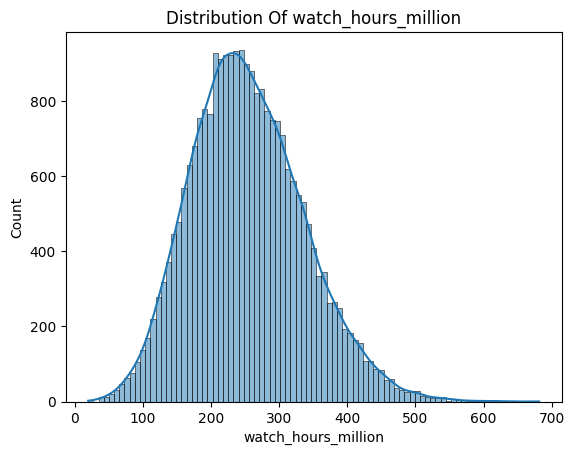

In [20]:
sns.histplot(df['watch_hours_million'],kde=True)
plt.title('Distribution Of watch_hours_million')
plt.show()

In [24]:
cols = [ x for x in df.columns if df[x].dtype == int or df[x].dtype == float]
cols

['release_year',
 'duration_minutes',
 'number_of_seasons',
 'total_episodes',
 'budget_million_usd',
 'marketing_spend_million_usd',
 'cast_popularity_score',
 'director_popularity_score',
 'imdb_rating',
 'critic_score',
 'trailer_views_million',
 'social_media_mentions_k',
 'watch_hours_million']

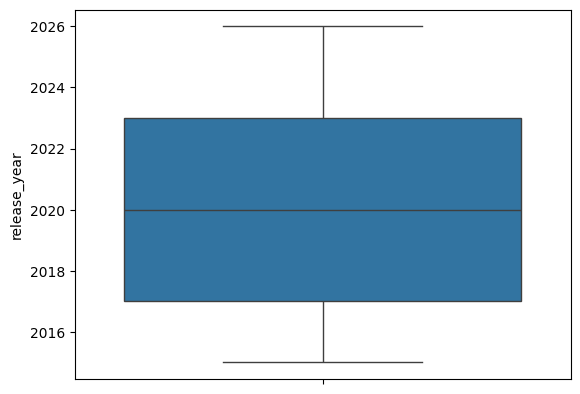

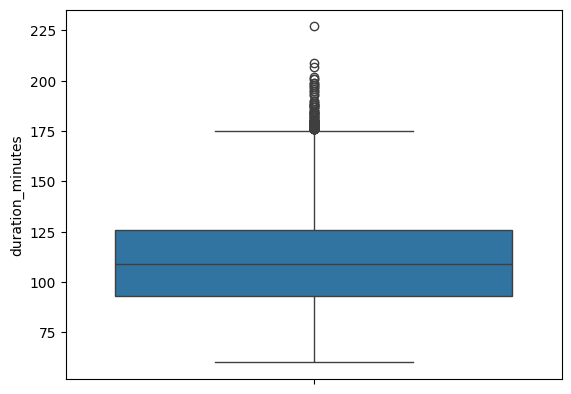

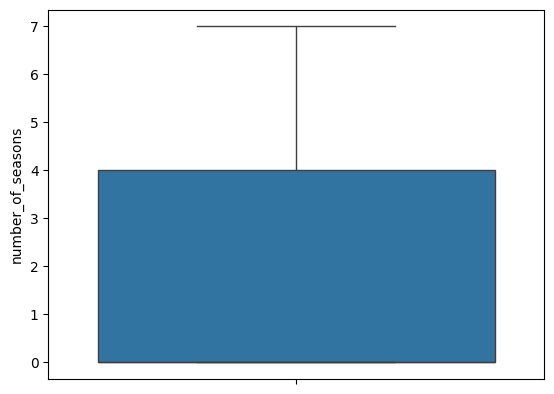

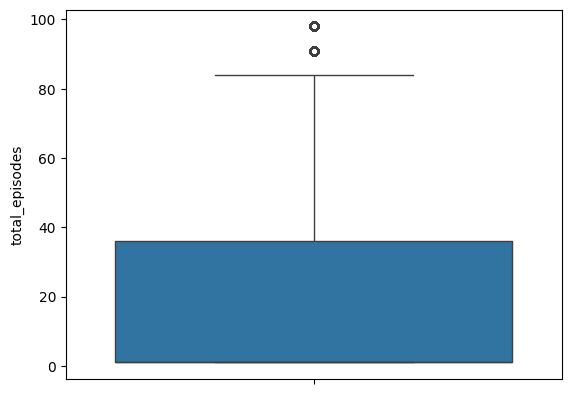

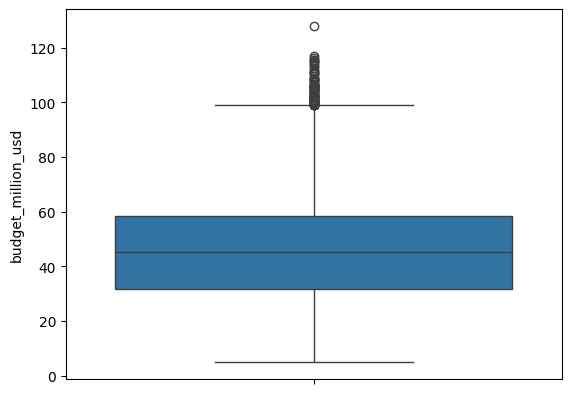

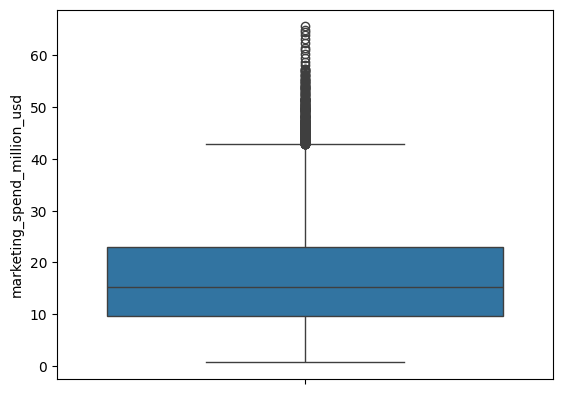

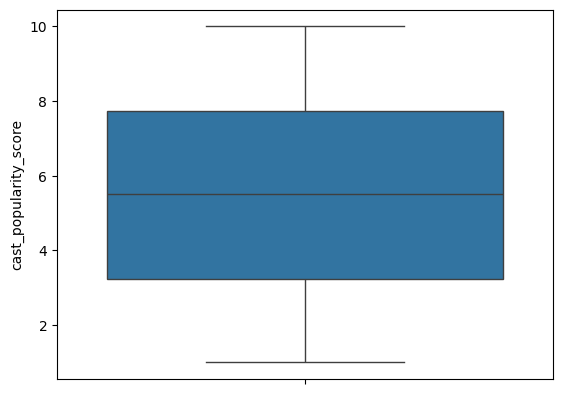

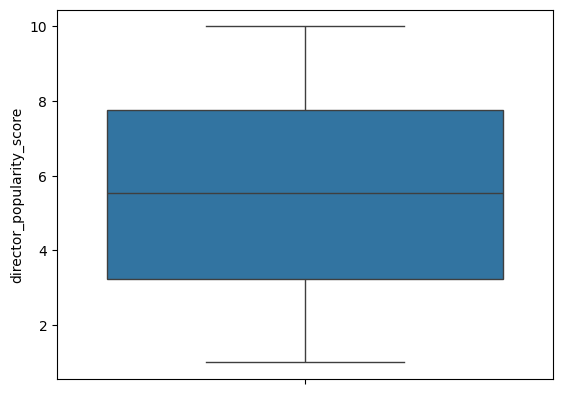

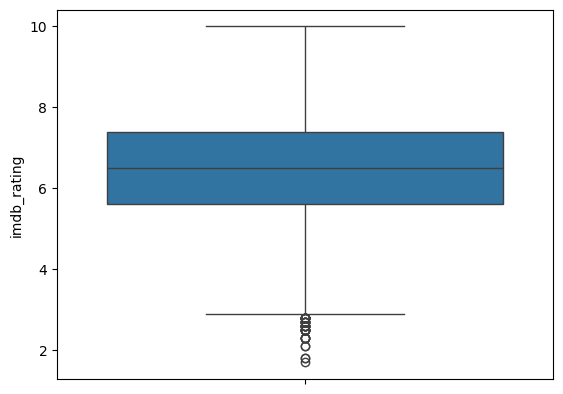

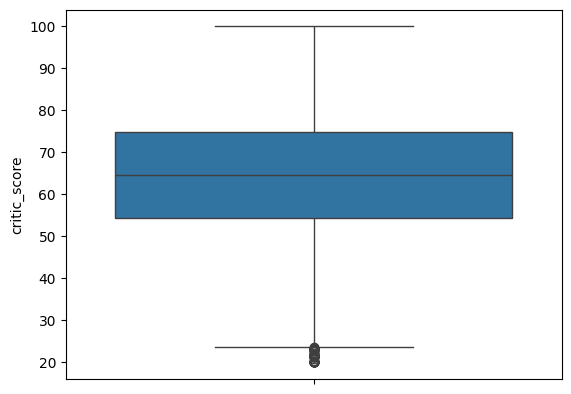

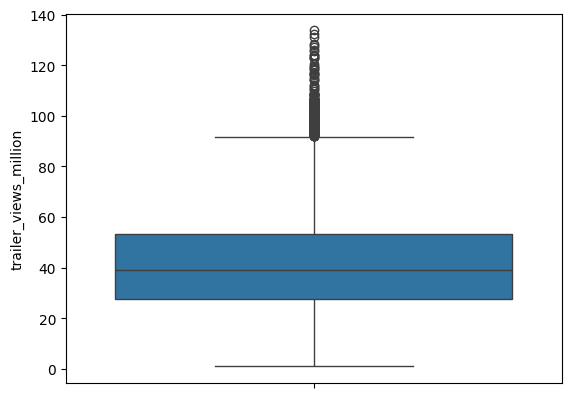

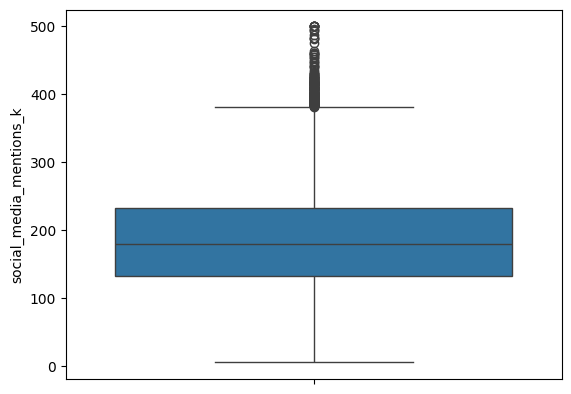

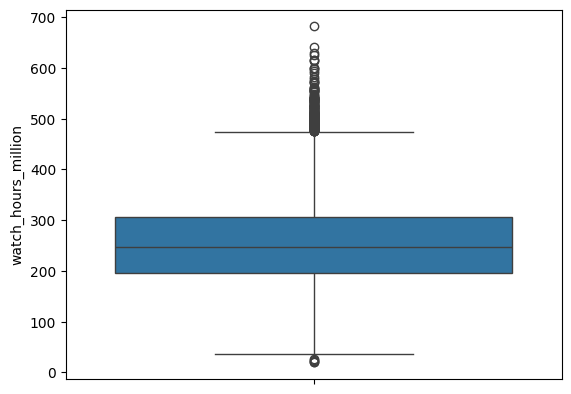

In [30]:
for i in cols:
  sns.boxplot(df[i])
  plt.show()

In [27]:
df_copy = df.copy()

In [28]:
for i in cols:
  Q1 = df_copy[i].quantile(0.25)
  Q3 = df_copy[i].quantile(0.75)

  iqr = Q3 - Q1

  upperlimit = Q3 + (1.5 * iqr)
  lowerlimit = Q1 - (1.5 * iqr)

  df_copy = df_copy[ (df_copy[i] > lowerlimit) & (df_copy[i] < upperlimit)]

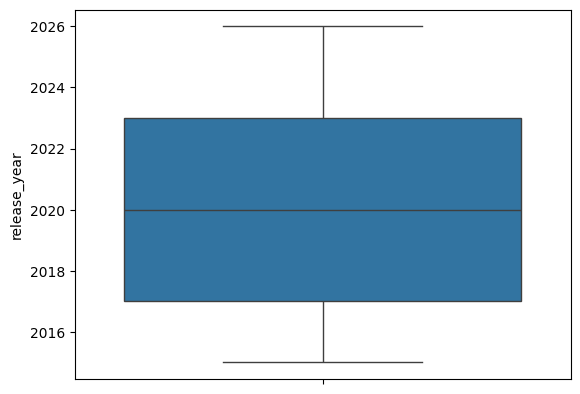

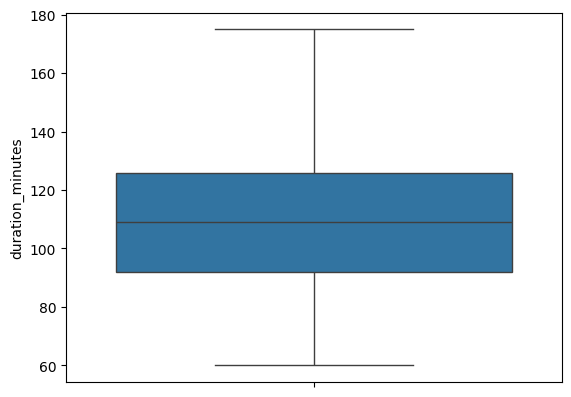

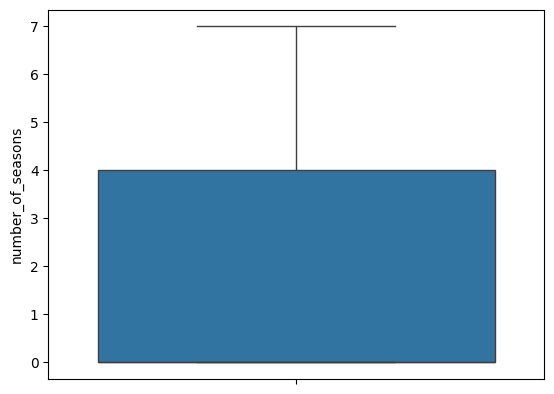

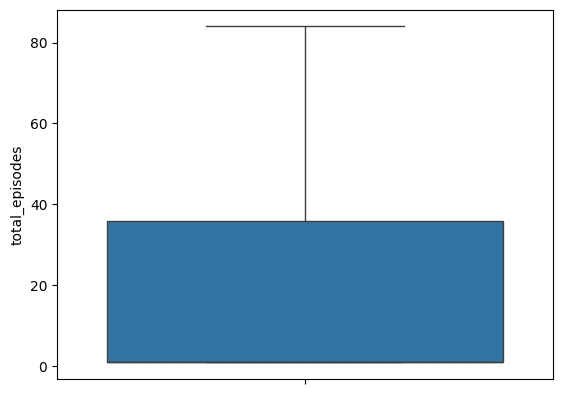

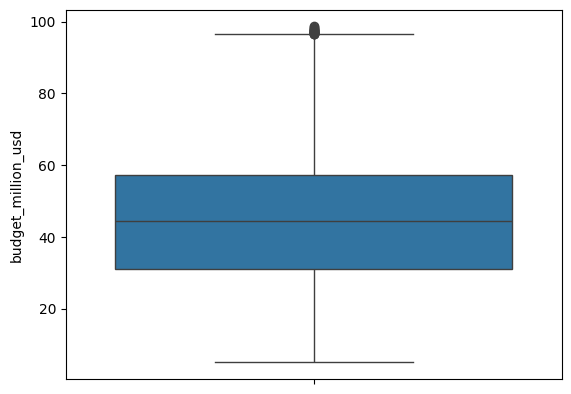

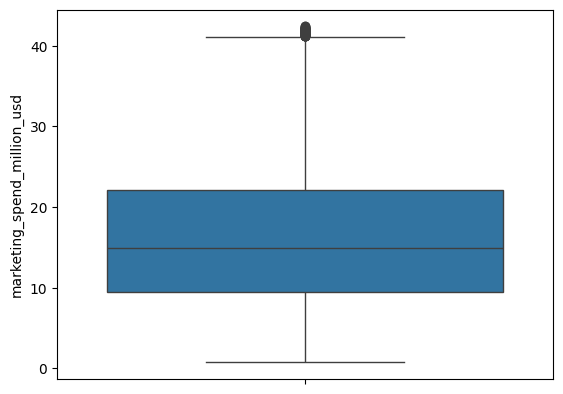

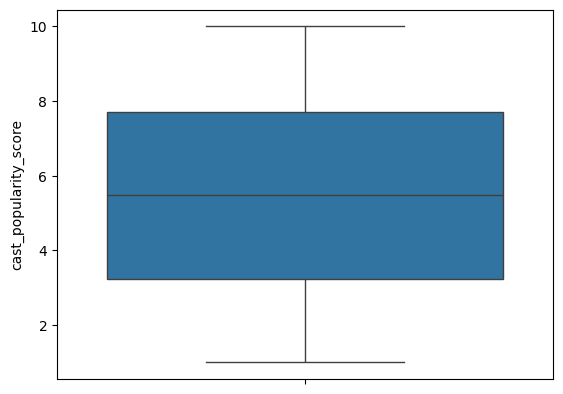

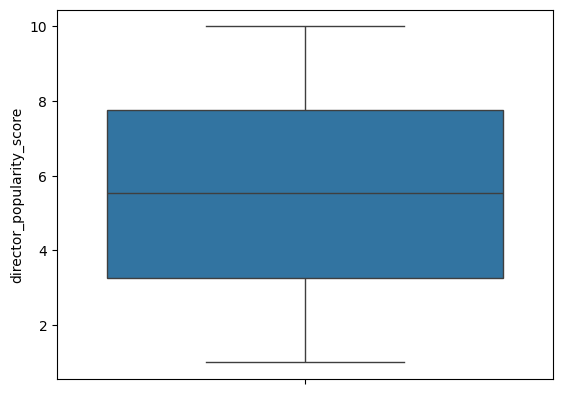

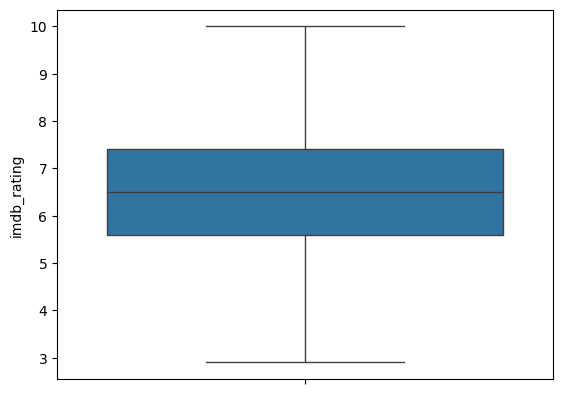

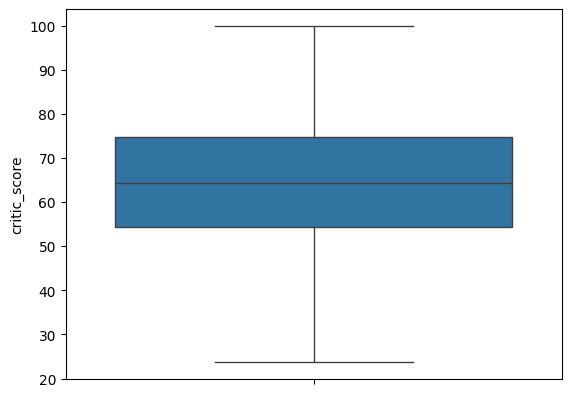

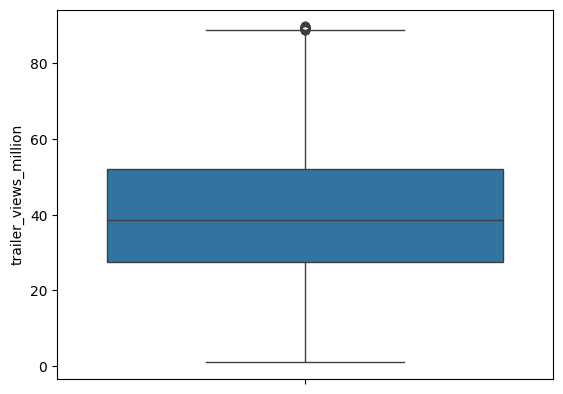

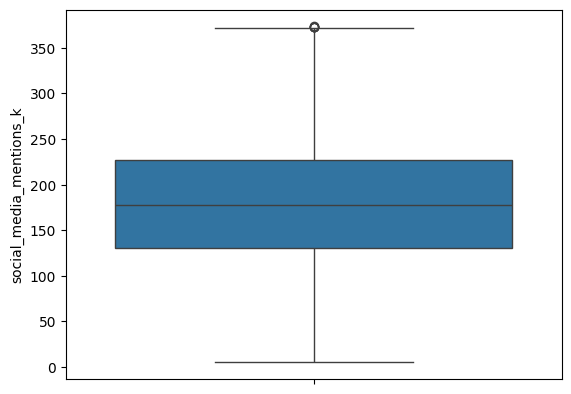

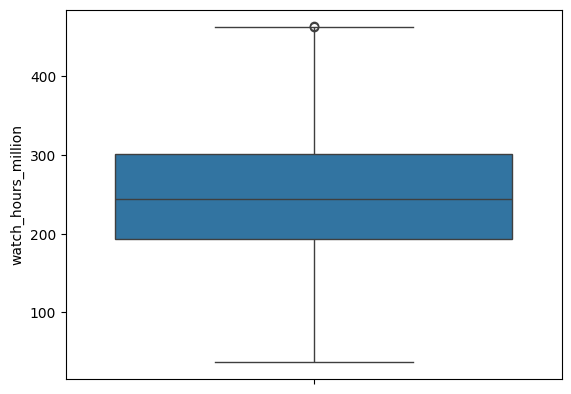

In [31]:
for i in cols:
  sns.boxplot(df_copy[i])
  plt.show()

<Axes: >

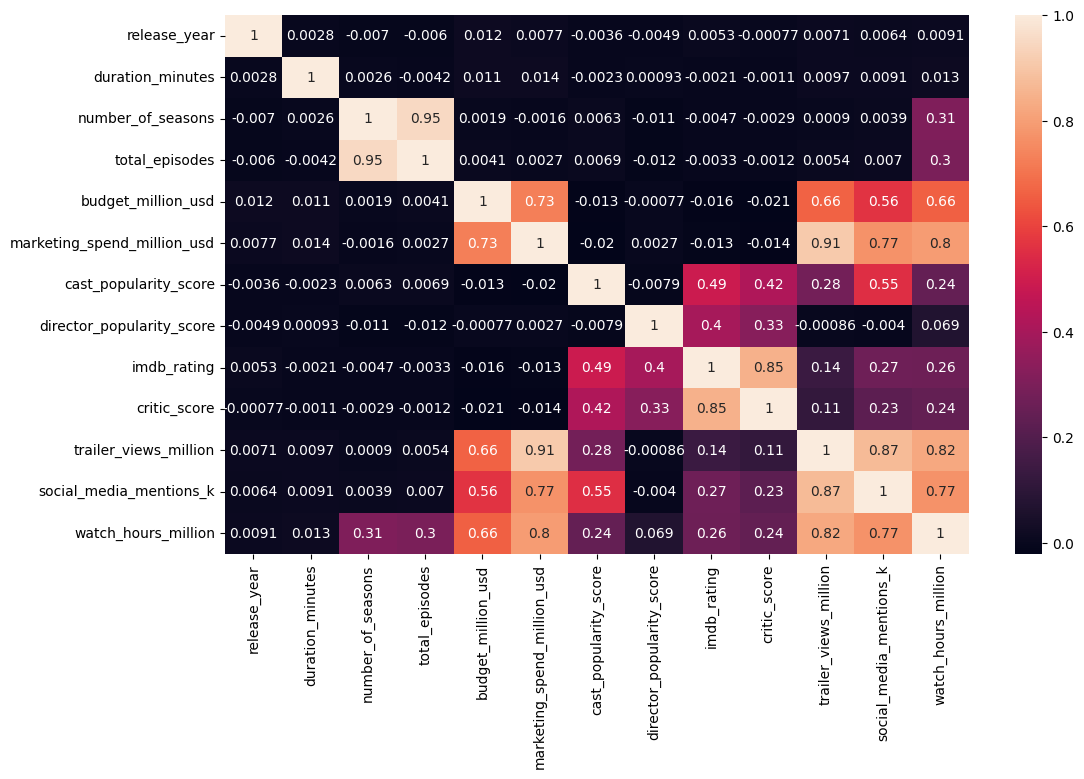

In [33]:
correlation = df_copy.corr(numeric_only=True)
plt.figure(figsize=(12,7))
sns.heatmap(correlation,annot=True)

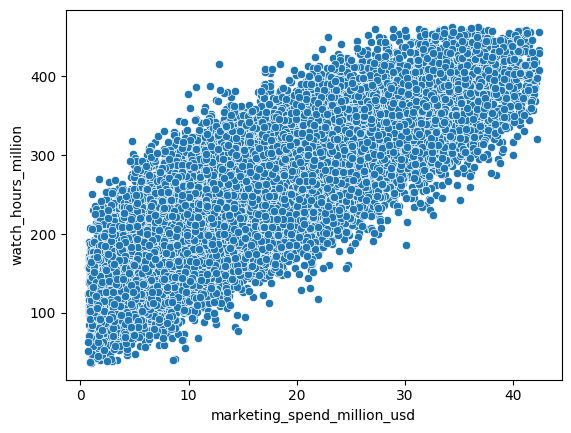

In [36]:
sns.scatterplot(x=df_copy['marketing_spend_million_usd'],y=df_copy['watch_hours_million'])
plt.show()

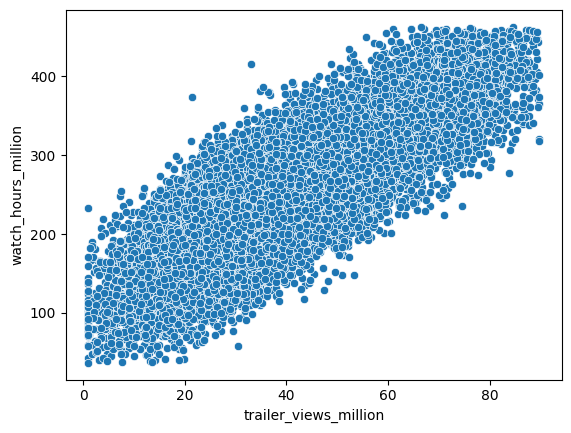

In [37]:
sns.scatterplot(x=df_copy['trailer_views_million'],y=df_copy['watch_hours_million'])
plt.show()

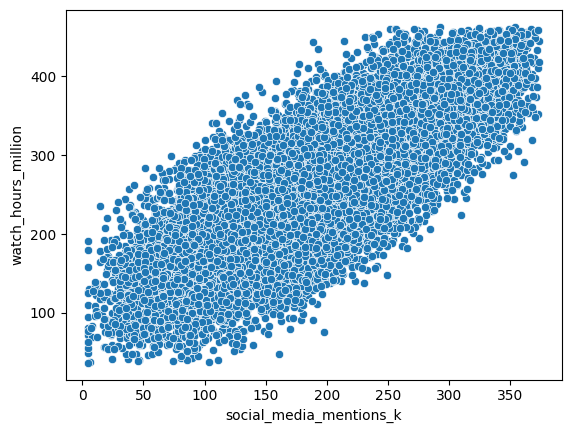

In [38]:
sns.scatterplot(x=df_copy['social_media_mentions_k'],y=df_copy['watch_hours_million'])
plt.show()

# Step 4 - Feature Engineering

Feature engineering improves model performance by creating meaningful features.

We will create:
- Budget to Marketing Ratio
- Popularity Index
- Episodes Per Season


In [40]:

df_copy['budget_marketing_ratio'] = (
    df_copy['budget_million_usd'] /
    (df_copy['marketing_spend_million_usd'] + 1)
)

df_copy['overall_popularity_score'] = (
    df_copy['cast_popularity_score'] * 0.7 +
    df_copy['director_popularity_score'] * 0.3
)

df_copy['episodes_per_season'] = (
    df_copy['total_episodes'] /
    (df_copy['number_of_seasons'] + 1)
)

df_copy.head()

,show_id,title,release_type,genre,language,country,release_year,release_day,duration_minutes,number_of_seasons,total_episodes,budget_million_usd,marketing_spend_million_usd,cast_popularity_score,director_popularity_score,imdb_rating,critic_score,trailer_views_million,social_media_mentions_k,subscription_plan_popularity,watch_hours_million,budget_marketing_ratio,overall_popularity_score,episodes_per_season
0,NFX000001,Adaptive disintermediate alliance,Movie,Drama,French,South Korea,2020,Tuesday,116,0,1,54.93,26.33,6.39,2.40,5.9,67.1,57.27,243.33,Basic,274.30,2.009879,5.193,1.0
1,NFX000002,Re-contextualized transitional benchmark,Movie,Comedy,French,Japan,2023,Friday,107,0,1,26.52,4.06,1.21,5.72,4.9,50.8,5.89,45.36,Basic,102.28,5.241107,2.563,1.0
2,NFX000003,Adaptive asymmetric conglomeration,Series,Drama,English,USA,2016,Tuesday,94,4,48,47.44,10.76,1.59,9.54,5.8,55.7,28.20,95.87,Basic,208.64,4.034014,3.975,9.6
3,NFX000004,Persevering content-based architecture,Movie,Fantasy,Hindi,Japan,2016,Saturday,114,0,1,21.82,9.78,3.81,5.68,4.8,53.9,26.08,113.52,Premium,141.91,2.024119,4.371,1.0
5,NFX000006,Expanded context-sensitive throughput,Movie,Documentary,Spanish,South Korea,2022,Tuesday,137,0,1,26.87,13.36,1.67,4.23,3.8,36.6,25.34,128.80,Basic,124.04,1.871170,2.438,1.0


# Step 5 - Define Features and Target

Features = Input variables

Target = Variable we want to predict


In [46]:
X = df_copy.drop(columns=[
    'watch_hours_million',
    'show_id',
    'title',
    'release_year',
    'duration_minutes',
    'director_popularity_score'
])

y = df_copy['watch_hours_million']


# Step 6 - Data Preprocessing

We will:

## Numerical Features
- Fill missing values using median
- Apply Standard Scaling

## Categorical Features
- Fill missing values using most frequent
- Apply One-Hot Encoding


In [47]:
numeric_columns = X.select_dtypes(exclude='object').columns
categorical_columns = X.select_dtypes(include='object').columns

In [48]:
numeric_columns

Index(['number_of_seasons', 'total_episodes', 'budget_million_usd',
       'marketing_spend_million_usd', 'cast_popularity_score', 'imdb_rating',
       'critic_score', 'trailer_views_million', 'social_media_mentions_k',
       'budget_marketing_ratio', 'overall_popularity_score',
       'episodes_per_season'],
      dtype='object')

In [49]:
categorical_columns

Index(['release_type', 'genre', 'language', 'country', 'release_day',
       'subscription_plan_popularity'],
      dtype='object')

In [50]:
ordinal_col = ['subscription_plan_popularity']

label_cols = [
    'release_type',
    'genre',
    'language',
    'country',
    'release_day'
]

In [65]:
numeric_transformer = Pipeline(
    steps = [
        ('imputer',SimpleImputer(strategy='median')),
        ('standard',StandardScaler())
    ]
)


categorical_Od_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('ordinal',OrdinalEncoder(categories=[['Basic','Standard','Premium']]))
    ]
)

categorical_Le_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('lebel',OrdinalEncoder())
    ]
)



In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformer,numeric_columns),
        ('categoryOD',categorical_Od_transformer,ordinal_col),
        ('categoryLE',categorical_Le_transformer,label_cols)
    ]
)

# Step 7 - Train-Test Split

We split the dataset:
- 80% Training
- 20% Testing


In [58]:
x_test,x_train,y_test,y_train = train_test_split(X,y,train_size=0.8,random_state=42)

# Step 8 - Linear Regression

In [68]:
linear_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LinearRegression())
    ]
)

linear_model.fit(x_train,y_train)
linear_predictions = linear_model.predict(x_test)

In [69]:

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

n = x_test.shape[0]
p = x_test.shape[1]

linear_adj_r2 = 1 - ((1 - linear_r2) * (n - 1) / (n - p - 1))

print("Linear Regression Metrics")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)
print("Adjusted R²:", linear_adj_r2)


Linear Regression Metrics
MAE: 23.857788501846507
MSE: 888.7159621753685
RMSE: 29.81133948978758
R²: 0.8472366958598112
Adjusted R²: 0.8470921249095208



# Step 9 - Polynomial Regression

In [75]:

poly_pipeline = Pipeline(
    steps=[
              ('preprocessor', preprocessor),
              ('poly', PolynomialFeatures(degree=2, include_bias=False)),
              ('model', LinearRegression())
         ]
    )

poly_pipeline.fit(x_train, y_train)

poly_predictions = poly_pipeline.predict(x_test)


In [76]:

poly_mae = mean_absolute_error(y_test, poly_predictions)
poly_mse = mean_squared_error(y_test, poly_predictions)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_predictions)

poly_adj_r2 = 1 - ((1 - poly_r2) * (n - 1) / (n - p - 1))

print("Polynomial Regression Metrics")
print("MAE:", poly_mae)
print("MSE:", poly_mse)
print("RMSE:", poly_rmse)
print("R²:", poly_r2)
print("Adjusted R²:", poly_adj_r2)


Polynomial Regression Metrics
MAE: 24.23072608078769
MSE: 918.4971863981079
RMSE: 30.306718502637462
R²: 0.8421175369752678
Adjusted R²: 0.8419681213951182



# Step 10 - Ridge Regression

Ridge Regression:
- Reduces overfitting
- Penalizes large coefficients
- Useful when multicollinearity exists


In [77]:

ridge_model = Pipeline(
    steps=[
             ('preprocessor', preprocessor),
             ('model', Ridge(alpha=1.0))
          ]
    )

ridge_model.fit(x_train, y_train)

ridge_predictions = ridge_model.predict(x_test)


In [78]:

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

ridge_adj_r2 = 1 - ((1 - ridge_r2) * (n - 1) / (n - p - 1))

print("Ridge Regression Metrics")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)
print("Adjusted R²:", ridge_adj_r2)


Ridge Regression Metrics
MAE: 23.85784728767186
MSE: 888.7314045497584
RMSE: 29.811598490348658
R²: 0.8472340414367604
Adjusted R²: 0.8470894679743977



# Step 11 - Lasso Regression

Lasso Regression:
- Performs feature selection
- Shrinks some coefficients to zero
- Helps reduce unnecessary variables


In [79]:
lasso_model = Pipeline(
    steps=[
            ('preprocessor', preprocessor),
            ('model', Lasso(alpha=0.1))
          ]
    )

lasso_model.fit(x_train, y_train)

lasso_predictions = lasso_model.predict(x_test)

In [80]:

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_predictions)

lasso_adj_r2 = 1 - ((1 - lasso_r2) * (n - 1) / (n - p - 1))

print("Lasso Regression Metrics")
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R²:", lasso_r2)
print("Adjusted R²:", lasso_adj_r2)


Lasso Regression Metrics
MAE: 23.855983596323497
MSE: 888.4845712952665
RMSE: 29.80745831659027
R²: 0.8472764701374169
Adjusted R²: 0.8471319368283987



# Step 12 - Elastic Net Regression

Elastic Net combines:
- Ridge Regression
- Lasso Regression

It balances:
- Regularization
- Feature Selection


In [81]:

elastic_model = Pipeline(
    steps=[
            ('preprocessor', preprocessor),
            ('model', ElasticNet(alpha=0.1, l1_ratio=0.5))
          ]
    )

elastic_model.fit(x_train, y_train)

elastic_predictions = elastic_model.predict(x_test)


In [82]:

elastic_mae = mean_absolute_error(y_test, elastic_predictions)
elastic_mse = mean_squared_error(y_test, elastic_predictions)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, elastic_predictions)

elastic_adj_r2 = 1 - ((1 - elastic_r2) * (n - 1) / (n - p - 1))

print("Elastic Net Metrics")
print("MAE:", elastic_mae)
print("MSE:", elastic_mse)
print("RMSE:", elastic_rmse)
print("R²:", elastic_r2)
print("Adjusted R²:", elastic_adj_r2)


Elastic Net Metrics
MAE: 23.95054240686568
MSE: 895.8295553263099
RMSE: 29.93041188033185
R²: 0.8460139249855412
Adjusted R²: 0.8458681968388397


# Step 13 - KNN Regression

K-Nearest Neighbors (KNN) Regression:
- Predicts target values based on the average of the nearest neighboring data points.
- Captures non-linear relationships in the data.
- Performance depends on the choice of K and feature scaling.

In [104]:
kreg_model = Pipeline(
    steps=[
            ('preprocessor', preprocessor),
            ('model', KNeighborsRegressor(n_neighbors=13))
        ]
    )

kreg_model.fit(x_train, y_train)

kreg_model_predictions = kreg_model.predict(x_test)

In [105]:
kr_mae = mean_absolute_error(y_test, kreg_model_predictions)
kr_mse = mean_squared_error(y_test, kreg_model_predictions)
kr_rmse = np.sqrt(kr_mse)
kr_r2 = r2_score(y_test, kreg_model_predictions)

kr_adj_r2 = 1 - ((1 - kr_r2) * (n - 1) / (n - p - 1))

print("KNN Regression Metrics")
print("MAE:", kr_mae)
print("MSE:", kr_mse)
print("RMSE:", kr_rmse)
print("R²:", kr_r2)
print("Adjusted R²:", kr_adj_r2)

Lasso Regression Metrics
MAE: 29.719633222494714
MSE: 1378.9755663694361
RMSE: 37.134560268965565
R²: 0.7629649147613544
Adjusted R²: 0.7627405913368384



# Step 14 — Model Comparison

Now we compare all models together.


In [107]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Elastic Net',
        'KNN Regression'
    ],
    'MAE': [
        linear_mae,
        poly_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        kr_mae
    ],
    'MSE': [
        linear_mse,
        poly_mse,
        ridge_mse,
        lasso_mse,
        elastic_mse,
        kr_mse
    ],
    'RMSE': [
        linear_rmse,
        poly_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        kr_rmse
    ],
    'R2 Score': [
        linear_r2,
        poly_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        kr_r2
    ],
    'Adjusted R2': [
        linear_adj_r2,
        poly_adj_r2,
        ridge_adj_r2,
        lasso_adj_r2,
        elastic_adj_r2,
        kr_adj_r2
    ]
})


results = results.sort_values(by='R2 Score', ascending=False)

results

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
3,Lasso Regression,23.855984,888.484571,29.807458,0.847276,0.847132
0,Linear Regression,23.857789,888.715962,29.811339,0.847237,0.847092
2,Ridge Regression,23.857847,888.731405,29.811598,0.847234,0.847089
4,Elastic Net,23.950542,895.829555,29.930412,0.846014,0.845868
1,Polynomial Regression,24.230726,918.497186,30.306719,0.842118,0.841968
5,KNN Regression,29.719633,1378.975566,37.134560,0.762965,0.762741


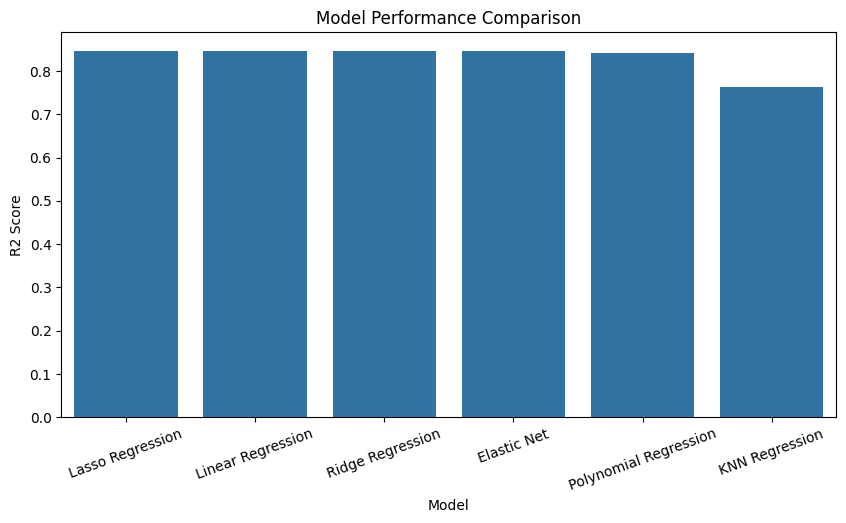

In [108]:

plt.figure(figsize=(10,5))
sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.xticks(rotation=20)
plt.title("Model Performance Comparison")
plt.show()
